# Analyse univariée et bivariée des données
## TP fil rouge : Parcoursup 2025

**Données** : formations proposées sur Parcoursup en 2025 (ministère de l'Enseignement supérieur, data.enseignementsup-recherche.gouv.fr).

**Organisation** : en binôme, un dépôt GitHub par binôme. Un commit à la fin de chaque partie.

Pour chaque question : du code, **et** une interprétation rédigée. Un chiffre sans phrase ne vaut rien.

---

### 🎯 La question de l'enquête

> **Qu'est-ce qui rend une formation sélective sur Parcoursup ?**

La sélectivité se mesure avec `taux_acces_ens` : la part des candidats qui ont reçu une proposition d'admission. Plus il est **bas**, plus la formation est **sélective**.

Chaque partie du TP fait avancer l'enquête. À la fin de chaque jour, vous rédigez une synthèse : *ce qu'on sait à ce stade sur la sélectivité*. La conclusion finale fait partie du TP noté.

# J1 matin — Comprendre les fondements de l'univarié

## Mise en place

Créez votre dépôt GitHub, clonez-le, placez `parcoursup.csv` dans un dossier `data/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Chargez le fichier (séparateur : `;`). Combien de lignes et de colonnes ?

In [22]:
df = pd.read_csv(
    'data/parcoursup.csv',
    sep=';',
    encoding='utf-8-sig',
    low_memory=False,
)

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 14252 lignes × 118 colonnes


,session,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0121471J,Institut national universitaire Champollion - ...,12,Aveyron,Occitanie,Toulouse,Rodez,Licence - Sciences et Techniques des Activités...,...,1_universités,2519,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,7.0,93,5,2,NaN,NaN
1,2025,Privé enseignement supérieur,0753605L,FAC LIBRE THEOLOGIE PROTESTANT,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Licence - Théologie - Parcours Théologie prote...,...,1_universités,25320,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,90,5,5,NaN,NaN
2,2025,Privé enseignement supérieur,0951809A,CY ILEPS,95,Val-d'oise,Ile-de-France,Versailles,Cergy,Licence - Sciences de l'éducation et de la for...,...,1_universités,25370,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,77.0,80,16,5,NaN,NaN
3,2025,Public,0922671D,I.U.T de Ville d'Avray - Antenne de Nanterre,92,Hauts-de-Seine,Ile-de-France,Versailles,Nanterre,BUT - Techniques de commercialisation,...,1_universités,25438,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,12.0,48,52,0,NaN,NaN
4,2025,Privé enseignement supérieur,0690195M,Institut Catholique de Lyon,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 2e Arrondissement,Licence - Double diplôme - Licence Droit - Dou...,...,1_universités,25443,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,60.0,100,0,0,NaN,NaN


## 1. Typologie des variables

🎯 *Enquête* : avant de chercher ce qui explique la sélectivité, il faut savoir quelles variables on a et comment les traiter.

Classez au moins ces colonnes : `fili`, `contrat_etab`, `select_form`, `cod_uai`, `capa_fin`, `voe_tot`, `taux_acces_ens`, `pct_bours`. Pour chacune : codage (ce que voit pandas), nature statistique, traitement retenu et justification.

| Variable | Codage (pandas) | Nature statistique | Traitement retenu | Justification |
|---|---|---|---|---|
| `fili` | `object`, 11 modalités | Qualitative nominale | Effectifs, mode, diagramme en barres | Du texte sans ordre : on ne peut pas faire de moyenne |
| `contrat_etab` | `object`, 4 modalités | Qualitative nominale | Effectifs, mode, camembert | Du texte sans ordre, et seulement 4 catégories |
| `select_form` | `object`, 2 modalités | Qualitative nominale | Proportions, sert à comparer deux groupes | Deux catégories seulement : pratique pour comparer |
| `cod_uai` | `object`, 4 058 modalités | Identifiant | Aucun calcul, sert à repérer l'établissement | Un code par établissement : il n'y a rien à analyser dessus |
| `capa_fin` | `int64`, 0 → 3 400 | Quantitative continue | Moyenne, médiane, écart-type, histogramme | Un nombre de places, avec beaucoup de valeurs différentes |
| `voe_tot` | `int64`, 1 → 19 404 | Quantitative continue | Moyenne, médiane, écart-type, histogramme | Un nombre de vœux, avec beaucoup de valeurs différentes |
| `taux_acces_ens` | `float64`, 0 → 100 | Quantitative continue | Moyenne, médiane, écart-type, boxplot | Un pourcentage, de 0 à 100 |
| `pct_bours` | `float64`, 0 → 100 | Quantitative continue | Moyenne, médiane, écart-type, histogramme | Un pourcentage, de 0 à 100 |


In [23]:
COLS = ['fili', 'contrat_etab', 'select_form', 'cod_uai',
        'capa_fin', 'voe_tot', 'taux_acces_ens', 'pct_bours']

typologie = pd.DataFrame([{
    'variable'  : c,
    'dtype'     : str(df[c].dtype),
    'modalites' : df[c].nunique(),
    'manquants' : df[c].isna().sum(),
    'min'       : df[c].min() if pd.api.types.is_numeric_dtype(df[c]) else '—',
    'max'       : df[c].max() if pd.api.types.is_numeric_dtype(df[c]) else '—',
    'exemple'   : df[c].dropna().iloc[0],
} for c in COLS])

typologie


,variable,dtype,modalites,manquants,min,max,exemple
0,fili,object,11,0,—,—,Licence
1,contrat_etab,object,4,0,—,—,Public
2,select_form,object,2,0,—,—,formation non sélective
3,cod_uai,object,4058,0,—,—,0121471J
4,capa_fin,int64,348,0,0,3400,20
5,voe_tot,int64,3244,0,1,19404,1065
6,taux_acces_ens,float64,101,15,0.0,100.0,7.0
7,pct_bours,float64,92,0,0.0,100.0,10.0


> 💾 **Commit** : « Typologie des variables »

## 2. Tendance centrale

🎯 *Enquête* : à quoi ressemble une formation « typique » ? Est-elle sélective ? On regarde d'abord la sélectivité, puis deux causes possibles : la demande (`voe_tot`) et la taille (`capa_fin`).

**2.1** Moyenne et médiane de `taux_acces_ens`. Que remarquez-vous ?

In [24]:
s = df['taux_acces_ens']

print(f"Moyenne : {s.mean():.2f} %")
print(f"Médiane : {s.median():.2f} %")


Moyenne : 56.15 %
Médiane : 54.00 %


**Interprétation** : moyenne 56,15 % et médiane 54 %, soit 2 points d'écart. Ces deux valeurs étant très proches, la distribution est à peu près symétrique : aucune valeur extrême ne tire la moyenne.

Une formation typique accepte donc un peu plus de la moitié de ses candidats.


**2.2** Moyenne et médiane de `voe_tot`. Une formation très demandée sera-t-elle forcément sélective ? Gardez la question en tête.

In [25]:
s = df['voe_tot']

print(f"Moyenne : {s.mean():.2f} vœux")
print(f"Médiane : {s.median():.0f} vœux")


Moyenne : 947.40 vœux
Médiane : 385 vœux


**Interprétation** : moyenne 947 vœux, médiane 385. La moyenne vaut 2,5 fois la médiane, les deux valeurs sont ici très éloignées.

C'est le signe d'une distribution étirée vers le haut : quelques formations reçoivent énormément de vœux et tirent la moyenne. La médiane décrit donc mieux la formation typique, avec 385 vœux.


**2.3** Quelle formation a la plus grande capacité (`capa_fin`) ? Que deviennent la moyenne et la médiane sans elle ?

In [45]:
i = df['capa_fin'].idxmax()
print(f' Formation avec la plus grande capacité : {df.loc[i, "lib_for_voe_ins"]} \n Établissement : {df.loc[i, "g_ea_lib_vx"]}\n Capacité : {df.loc[i, "capa_fin"]} places')
print("---"* 38)

avec = df['capa_fin']
sans = avec.drop(i)

print(f"Avec : moyenne {round(avec.mean(), 2)}, médiane {avec.median()}")
print(f"Sans : moyenne {round(sans.mean(), 2)}, médiane {sans.median()}")


 Formation avec la plus grande capacité : BTS - Services - Diététique et nutrition - Entièrement en distanciel 
 Établissement : CNED
 Capacité : 3400 places
------------------------------------------------------------------------------------------------------------------
Avec : moyenne 53.98, médiane 30.0
Sans : moyenne 53.75, médiane 30.0


**Interprétation** : la plus grande capacité est un BTS Diététique et nutrition du CNED, avec 3 400 places. C'est une formation entièrement à distance, donc sans contrainte de salle.

En la retirant, la moyenne passe de 53,98 à 53,75 places et la médiane reste à 30.

La médiane ne bouge pas parce qu'elle dépend du rang des valeurs, pas de leur montant. La moyenne baisse à peine, parce qu'une valeur sur 14 252 pèse peu.


**2.4** Mode de `fili` et de `contrat_etab`.

In [27]:
print(f"Mode de fili :{df['fili'].mode()  [0]}")
print(f"Mode de contrat_etab :{df['contrat_etab'].mode()[0]}")

Mode de fili :BTS
Mode de contrat_etab :Public


**Interprétation** : la filière la plus fréquente est le BTS, et le statut d'établissement le plus fréquent est Public.


> 💾 **Commit** : « Tendance centrale »

## 3. Dispersion

🎯 *Enquête* : les formations sont-elles toutes à peu près aussi sélectives, ou y a-t-il de grands écarts à expliquer ?

On étudie la dispersion de `voe_tot` de bout en bout, puis on la compare à `taux_acces_ens`.

**3.1** Étendue de `voe_tot` (minimum, maximum, étendue).

In [46]:
s = df['voe_tot']

print(f"Minimum : {s.min()}")
print(f"Maximum : {s.max()}")
print(f"Étendue : {s.max() - s.min()}")


Minimum : 1
Maximum : 19404
Étendue : 19403


**Interprétation** : la formation la moins demandée a reçu 1 vœu, la plus demandée 19 404, soit une étendue de 19 403 vœux.

L'écart entre les deux extrêmes est donc considérable. Mais l'étendue ne s'appuie que sur ces deux valeurs.


**3.2** Variance pas à pas sur les **10 premières formations** : écarts à la moyenne, écarts au carré, somme des écarts. Calculez la variance en divisant par n, puis par n − 1. Vérifiez avec numpy et pandas.

In [73]:
ech = df['voe_tot'].sample(10, random_state=37)
m = ech.mean()

etapes = pd.DataFrame({
    'voe_tot': ech,
    'ecart': ech - m,
    'ecart_carre': (ech - m) ** 2,
})
print(f"ETAPES : \n {etapes}")
print("---"* 38)

print(f"Moyenne          : {m}")
print(f"Somme des écarts : {etapes['ecart'].sum():.2f}")
print(f"Somme des carrés : {etapes['ecart_carre'].sum()}\n")
print("---"* 38)

n = len(ech)
print("CALCUL MANUEL DE LA VARIANCE")
print(f"Variance / n     : {etapes['ecart_carre'].sum() / n:.2f}")
print(f"Variance / (n-1) : {etapes['ecart_carre'].sum() / (n - 1):.2f}\n")

print("CALCUL AVEC NUMPY")
print(f"np.var(ech)        : {np.var(ech):.2f}")
print(f"np.var(ech, ddof=1): {np.var(ech, ddof=1):.2f}\n")

print("CALCUL AVEC PANDAS")
print(f"ech.var()          : {ech.var():.2f}")
print(f"ech.var(ddof=0)    : {ech.var(ddof=0):.2f}")


ETAPES : 
        voe_tot   ecart  ecart_carre
14180      742  -146.2     21374.44
9768       518  -370.2    137048.04
6150       459  -429.2    184212.64
2799       411  -477.2    227719.84
5669       659  -229.2     52532.64
2967      2523  1634.8   2672571.04
9609      1427   538.8    290305.44
3481      1348   459.8    211416.04
6031        41  -847.2    717747.84
6437       754  -134.2     18009.64
------------------------------------------------------------------------------------------------------------------
Moyenne          : 888.2
Somme des écarts : -0.00
Somme des carrés : 4532937.6

------------------------------------------------------------------------------------------------------------------
CALCUL MANUEL DE LA VARIANCE
Variance / n     : 453293.76
Variance / (n-1) : 503659.73

CALCUL AVEC NUMPY
np.var(ech)        : 453293.76
np.var(ech, ddof=1): 503659.73

CALCUL AVEC PANDAS
ech.var()          : 503659.73
ech.var(ddof=0)    : 453293.76


**Interprétation** : la somme des écarts vaut 0, parce que les écarts positifs annulent les négatifs. C'est pour cela qu'on les met au carré.

La variance vaut 453 294 si on divise par n, et 503 660 si on divise par n − 1. On divise par n − 1 car les 10 formations sont un échantillon, pas toutes les formations.

`numpy` divise par n par défaut, `pandas` par n − 1.


**3.3** Calculez tous les indicateurs de dispersion de `voe_tot` : variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation. Comparez l'écart-type, l'écart absolu moyen et l'IQR.

In [74]:
s = df['voe_tot']

q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
ecart_type = s.std()
ecart_absolu_moyen = (s - s.mean()).abs().mean()

print(f"Variance           : {s.var():.2f}")
print(f"Écart-type         : {ecart_type:.2f}")
print(f"Écart absolu moyen : {ecart_absolu_moyen:.2f}")
print(f"Q1                 : {q1:.0f}")
print(f"Q3                 : {q3:.0f}")
print(f"IQR                : {q3 - q1:.0f}")
print(f"Coef. de variation : {ecart_type / s.mean():.2%}")


Variance           : 2509634.09
Écart-type         : 1584.18
Écart absolu moyen : 929.90
Q1                 : 160
Q3                 : 1016
IQR                : 856
Coef. de variation : 167.21%


**Interprétation** : l'écart-type (1 584) est bien plus grand que l'écart absolu moyen (930) et que l'IQR (856). L'écart-type élève les écarts au carré, il donne donc beaucoup de poids aux formations très demandées, alors que l'IQR ne regarde que la moitié centrale et ignore les extrêmes.

Le coefficient de variation atteint 167 % : l'écart-type dépasse la moyenne, ce qui signale une dispersion très forte.


**3.4** Comparez la dispersion de `voe_tot` et de `taux_acces_ens` (écart-type, IQR, coefficient de variation). Laquelle est la plus dispersée ? Qu'est-ce que ça dit des écarts de sélectivité entre formations ?

In [75]:
for c in ['voe_tot', 'taux_acces_ens']:
    s = df[c].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    print(f"{c}")
    print(f"  Écart-type         : {s.std():.2f}")
    print(f"  IQR                : {q3 - q1:.0f}")
    print(f"  Coef. de variation : {s.std() / s.mean():.2%}\n")


voe_tot
  Écart-type         : 1584.18
  IQR                : 856
  Coef. de variation : 167.21%

taux_acces_ens
  Écart-type         : 28.59
  IQR                : 48
  Coef. de variation : 50.92%



**Interprétation** : les deux variables n'ont pas la même unité, des vœux d'un côté et des pourcentages de l'autre. L'écart-type et l'IQR ne sont donc pas comparables entre elles ; seul le coefficient de variation le permet, puisqu'il rapporte la dispersion à la moyenne.

`voe_tot` est trois fois plus dispersée que `taux_acces_ens` (167 % contre 51 %). Les écarts de demande entre formations sont donc bien plus marqués que les écarts de sélectivité.

La sélectivité varie malgré tout beaucoup : la moitié centrale des formations s'étale de 33 % à 81 % d'accès, soit 48 points d'écart.


> 💾 **Commit** : « Dispersion »

## 4. Graphiques

🎯 *Enquête* : voir la sélectivité, et trouver un premier indice de ce qui la fait varier.

**4.1** Histogramme de `taux_acces_ens`. À quelle forme vous attendiez-vous ? Qu'obtenez-vous ?

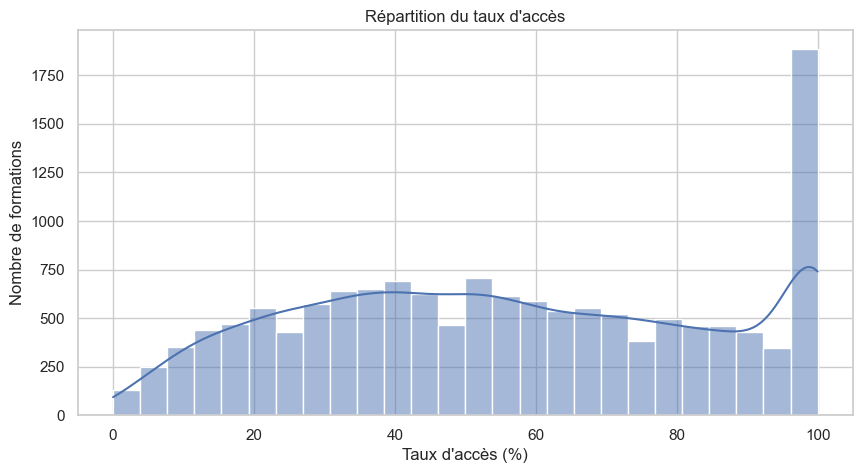

In [79]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='taux_acces_ens', kde=True)

plt.xlabel("Taux d'accès (%)")
plt.ylabel("Nombre de formations")
plt.title("Répartition du taux d'accès")
plt.show()


**Interprétation** : on attendait une courbe en cloche, on obtient une distribution presque plate entre 20 % et 90 %. Le seul pic est à 100 %, les formations qui acceptent tous leurs candidats.


**4.2** Diagramme en barres de `fili`, trié par effectif.

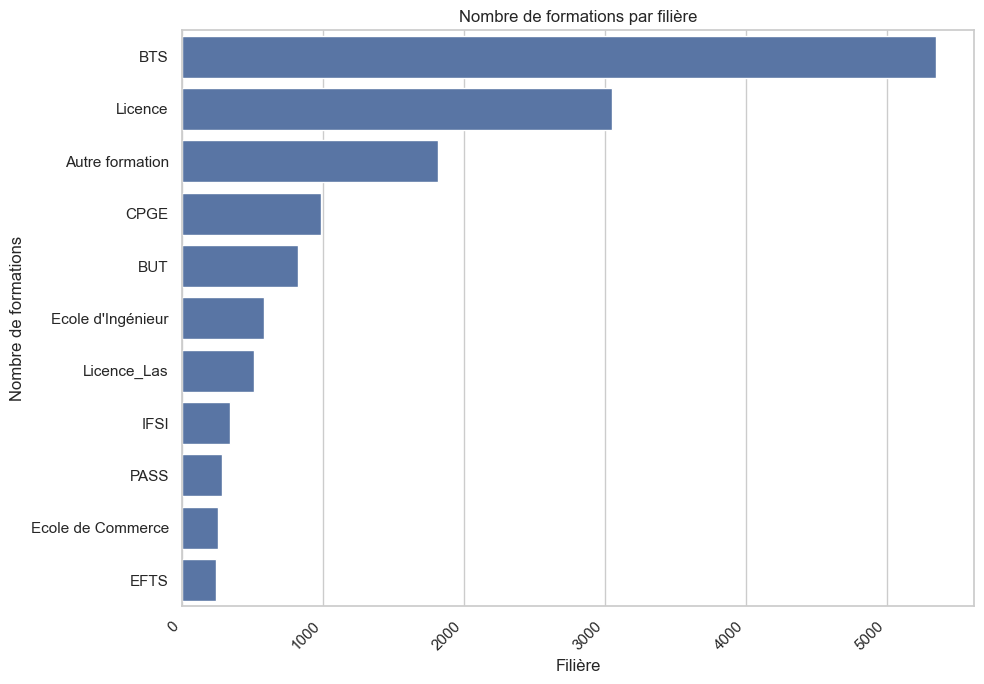

In [93]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, y='fili', order=df['fili'].value_counts().index)
plt.xlabel("Filière")
plt.ylabel("Nombre de formations")
plt.title("Nombre de formations par filière")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**4.2 bis** Camembert de `contrat_etab`, puis camembert de `fili`. Lequel est lisible ? Pourquoi ?

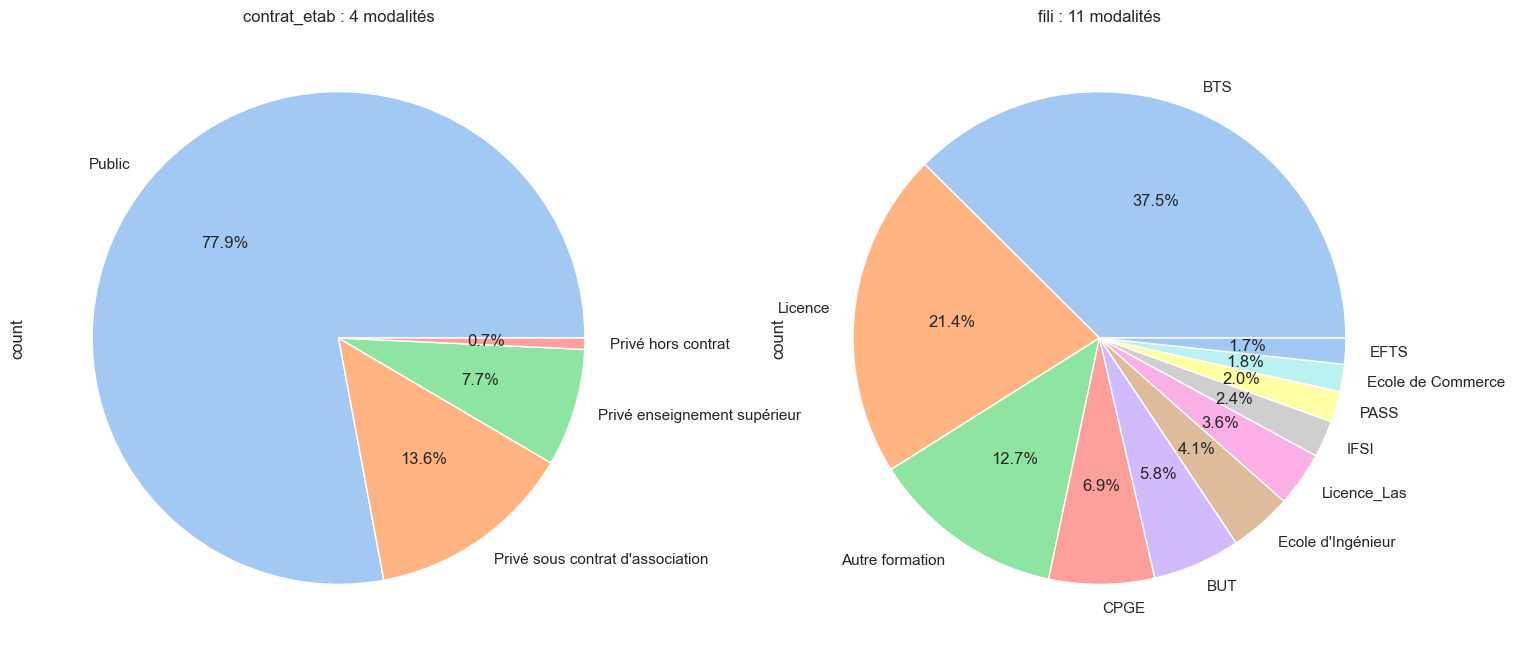

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
couleurs = sns.color_palette('pastel')

df['contrat_etab'].value_counts().plot.pie(autopct='%1.1f%%', colors=couleurs, ax=axes[0])
axes[0].set_title("contrat_etab : 4 modalités")


df['fili'].value_counts().plot.pie(autopct='%1.1f%%', colors=couleurs, ax=axes[1])
axes[1].set_title("fili : 11 modalités")

plt.show()


**Interprétation** : le camembert de `contrat_etab` est lisible, avec 4 parts dont une qui occupe près de 80 %. Celui de `fili` ne l'est pas : sur 11 parts, cinq passent sous 4 % et deviennent indistinguables, avec des étiquettes qui se chevauchent.


**4.3** Boxplot de `voe_tot`. Est-il lisible ? Que faudrait-il faire ?

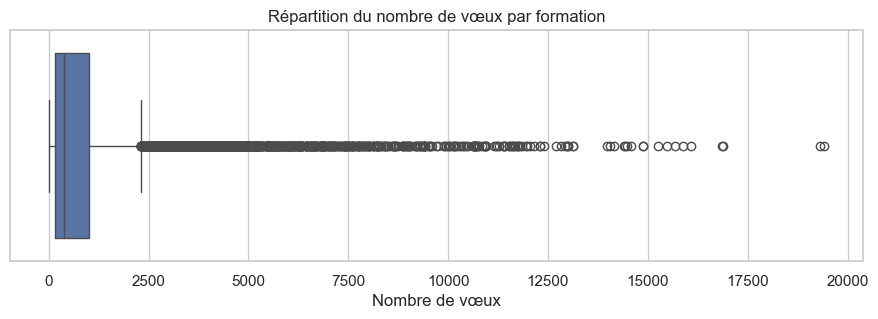

In [112]:
plt.figure(figsize=(11, 3))
sns.boxplot(data=df, x='voe_tot')
plt.xlabel("Nombre de vœux")
plt.title("Répartition du nombre de vœux par formation")
plt.show()


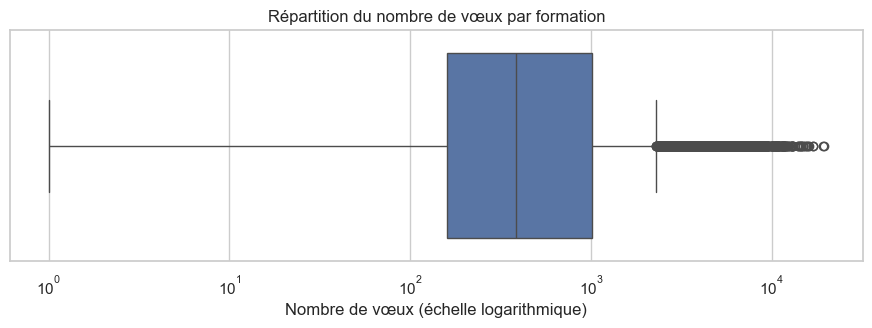

In [102]:
plt.figure(figsize=(11, 3))
sns.boxplot(data=df, x='voe_tot')
plt.xscale('log')
plt.xlabel("Nombre de vœux (échelle logarithmique)")
plt.title("Répartition du nombre de vœux par formation")
plt.show()


**Interprétation** : le boxplot n'est pas lisible. La boîte est écrasée contre l'axe par une longue traînée de points extrêmes qui s'étire jusqu'à 19 404 vœux.

Il faut passer l'axe en échelle logarithmique : la boîte et la médiane redeviennent visibles.


**Interprétation** : _à rédiger_

> 💾 **Commit** : « Graphiques », puis **push**.

# J1 après-midi — Approfondir les distributions

In [ ]:
from scipy import stats

## 5. Asymétrie et aplatissement

🎯 *Enquête* : la forme des variables décidera des outils à utiliser au J2 pour les relier à la sélectivité.

**5.1** Calculez la skewness et la kurtosis de `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`. Classez-les de la plus symétrique à la plus asymétrique. Lesquelles faudra-t-il transformer avant de les relier à la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Asymétrie »

## 6. La loi normale

🎯 *Enquête* : peut-on utiliser sur la sélectivité les outils qui supposent une loi normale ?

**6.1** Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`. La variable suit-elle une loi normale ? Quelle conséquence pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Loi normale »

## 7. Les distributions réelles

🎯 *Enquête* : la demande (`voe_tot`) est une cause possible de sélectivité. Quelle échelle faudra-t-il utiliser pour la comparer au taux d'accès ?

**7.1** Tracez l'histogramme de `voe_tot`, puis celui de `log(voe_tot)`. Quelle loi reconnaissez-vous ? Quelle échelle utiliserez-vous au J2 pour relier la demande à la sélectivité ?

**Interprétation** : _à rédiger_

**7.2** Quelle part des vœux concentrent les 10 % et les 20 % de formations les plus demandées ? Est-ce une distribution de type Pareto ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Distributions »

## 8. Outliers

🎯 *Enquête* : les formations hors norme risquent de fausser les liens avec la sélectivité. Faut-il les garder ?

**8.1** Détectez les outliers de `capa_fin` avec la méthode IQR, puis avec le Z-score (|z| > 3). Comparez les nombres obtenus et expliquez l'écart.

**Interprétation** : _à rédiger_

**8.2** Affichez les 10 plus grandes capacités. S'agit-il d'erreurs ou de valeurs réelles ? Que faites-vous ? Les garderez-vous pour étudier la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Outliers », puis **push**.

## 9. Analyse univariée en autonomie

🎯 *Enquête* : deux nouveaux suspects. Le profil social des admis et la région peuvent-ils jouer sur la sélectivité ?

Vous disposez maintenant de toute la méthode. Analysez **seuls** les deux variables suivantes, en suivant les étapes ci-dessous :
- une variable **quantitative** : `pct_bours` (part de boursiers parmi les admis, en %) ;
- une variable **qualitative** : `region_etab_aff` (région de l'établissement).

| Étape | Variable quantitative | Variable qualitative |
|---|---|---|
| 1. Comprendre | Ce qu'elle mesure, son unité, discrète ou continue | Nominale ou ordinale, liste des modalités |
| 2. Qualité | Valeurs manquantes, 0 suspects, bornes | Valeurs manquantes, modalités mal orthographiées |
| 3. Centre | Moyenne et médiane, comparées | Mode (et médiane si ordinale) |
| 4. Dispersion | σ, IQR, CV | Nombre de modalités, part de la modalité dominante |
| 5. Visualiser | Histogramme, boxplot | Diagramme en barres |
| 6. Forme | Skewness, kurtosis, QQ-plot : quelle loi ? | Répartition équilibrée ou concentrée, modalités rares |
| 7. Extrêmes | IQR ou Z-score selon la forme, puis inspection | — |
| 8. Conclure | Quel résumé, quels outils pour la suite ? | Quel regroupement, quel encodage pour la suite ? |

> Chaque chiffre s'interprète en une phrase.

### Variable quantitative : `pct_bours`

**Analyse** : _à rédiger_

### Variable qualitative : `region_etab_aff`

**Analyse** : _à rédiger_

> 💾 **Commit** : « Analyse univariée », puis **push**.

## 📝 Synthèse J1 — Ce qu'on sait sur la sélectivité

- À quoi ressemble la sélectivité d'une formation typique ? Les formations sont-elles proches ou très différentes ?
- Quels premiers indices avez-vous trouvés sur ce qui la fait varier ?
- Quelles variables faudra-t-il transformer pour la suite, et pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J1 », puis **push**.

# J2 matin — Mettre en pratique les fondements mathématiques de la corrélation

## 10. Covariance

🎯 *Enquête* : on passe au bivarié. On apprend d'abord à mesurer un lien sur un couple simple (capacité × vœux), avant de l'appliquer à la sélectivité.

**10.1** Tracez le nuage de points de `voe_tot` en fonction de `capa_fin`. Calculez leur covariance à la main (produits des écarts), puis avec pandas.

**Interprétation** : _à rédiger_

**10.2** Recalculez la covariance avec la capacité exprimée en centaines de places. Que constatez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Covariance »

## 11. Corrélation de Pearson

🎯 *Enquête* : première mesure chiffrée du lien entre la demande et la sélectivité.

**11.1** Calculez r entre `capa_fin` et `voe_tot` à la main (covariance / produit des écarts-types), puis avec pandas. Faites de même pour `voe_tot` et `taux_acces_ens`. Que dit ce second coefficient sur la sélectivité ?

**Interprétation** : _à rédiger_

**11.2** Les conditions de Pearson sont-elles respectées ? Recalculez r entre `log(capa_fin)` et `log(voe_tot)` (en excluant les valeurs nulles).

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Pearson »

## 12. Corrélation de Spearman

🎯 *Enquête* : le lien demande × sélectivité est-il sous-estimé par Pearson ?

**12.1** Calculez Spearman pour les deux couples de la question 11.1. Comparez avec Pearson et expliquez les écarts.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Spearman »

## 13. Tests d'hypothèse

🎯 *Enquête* : le lien entre demande et sélectivité est-il réel, ou dû au hasard ? Et quel coefficient retenir pour la suite ?

**13.1** Testez la normalité de `taux_acces_ens` avec Shapiro-Wilk et Anderson-Darling, sur un échantillon de 50 formations puis sur toutes. Formulez H0 et concluez. Quel coefficient de corrélation retiendrez-vous pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

**13.2** Testez la corrélation entre `voe_tot` et `taux_acces_ens` (Spearman). Formulez H0, donnez la p-value et concluez. Le lien est-il fort pour autant ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Tests », puis **push**.

# J2 après-midi — Approfondir les relations quantitatives

## 14. Corrélation partielle

🎯 *Enquête* : le lien entre demande et sélectivité tient-il à capacité égale ?

**14.1** Calculez la corrélation entre `log(voe_tot)` et `taux_acces_ens`, puis la corrélation partielle en contrôlant `log(capa_fin)`. Que concluez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Corrélation partielle »

## 15. A/B testing

🎯 *Enquête* : un lien observé suffit-il à affirmer qu'un facteur *cause* la sélectivité ?

**15.1** Au J3, vous verrez que les formations privées ont un taux d'accès plus élevé que les publiques. Peut-on en conclure que le statut privé *rend* une formation moins sélective ? Quelle expérience faudrait-il pour le prouver, et est-elle possible ici ?

**Interprétation** : _à rédiger_

**15.2** Reprenez la simulation de la démo avec 500 visiteurs, puis 20 000. Une version B qui fait passer le taux d'achat de 20 % à 22 %. L'effet est-il détecté dans les deux cas ? Pourquoi ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « A/B testing »

## 16. Matrice de corrélation

🎯 *Enquête* : vue d'ensemble. Quelles variables quantitatives sont liées à la sélectivité, et lesquelles disent la même chose ?

**16.1** Tracez la heatmap des corrélations de Spearman entre `capa_fin`, `voe_tot`, `acc_tot`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb`. Quelles variables sont redondantes ? Quelles variables sont les meilleures candidates pour expliquer la sélectivité ?

**Interprétation** : _à rédiger_

## 17. Régression simple

🎯 *Enquête* : le niveau scolaire des admis explique-t-il la sélectivité, et dans quelle mesure ?

**17.1** Régressez `taux_acces_ens` sur `pct_tb` (part de mentions très bien parmi les admis). Donnez la pente, le R², et tracez les résidus. Les mentions TB expliquent-elles la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Régression », puis **push**.

## 📝 Synthèse J2 — Ce qu'on sait sur la sélectivité

- Quelles variables quantitatives sont liées à la sélectivité, avec quelle force ?
- Le lien avec la demande tient-il quand on contrôle la taille ?
- Peut-on parler de causes ? Pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J2 », puis **push**.

# J3 matin — Comprendre les fondements du bivarié qualitatif

## 18. Table de contingence et Chi²

🎯 *Enquête* : le label « formation sélective » dépend-il du statut de l'établissement ?

**18.1** Croisez `select_form` et `contrat_etab` : table des effectifs, puis fréquences conditionnelles par statut.

**Interprétation** : _à rédiger_

**18.2** Faites le test du Chi² d'indépendance (H0, effectifs théoriques, p-value), puis calculez le V de Cramér et les résidus standardisés.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Chi² »

## 19. Quantitatif × qualitatif

🎯 *Enquête* : la sélectivité varie-t-elle selon le statut (public / privé) et selon la filière ?

**19.1** Le `taux_acces_ens` diffère-t-il entre formations publiques et privées ? Boxplot, Student (Welch) et Mann-Whitney.

**Interprétation** : _à rédiger_

**19.2** Le `taux_acces_ens` diffère-t-il selon la filière (`fili`) ? ANOVA et Kruskal-Wallis. Quelles filières sont les plus sélectives ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Quanti × quali », puis **push**.

# J3 après-midi — Introduire le multivarié

## 20. ACP

🎯 *Enquête* : on rassemble toutes les variables. Où se place la sélectivité parmi elles ?

**20.1** Faites une ACP sur `log(capa_fin)`, `log(voe_tot)`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb` (centrées-réduites). Quelle part de variance portent les deux premiers axes ? Interprétez-les à partir des contributions. Où se place `taux_acces_ens` sur ces axes ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « ACP », puis **push**.

## 🏁 Conclusion de l'enquête

Répondez à la question : **qu'est-ce qui rend une formation sélective sur Parcoursup ?**

- Les facteurs retenus, classés par importance, chacun appuyé par un chiffre du TP.
- Les pistes écartées.
- Les limites : ce que vos analyses ne permettent pas d'affirmer.

10 à 15 lignes. Cette conclusion compte dans la note du TP.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Conclusion de l'enquête », puis **push**.